In [6]:
import os
import pandas as pd
import numpy as np

print("Loading RanSMAP memory telemetry...")

base = r"C:\Users\User\Downloads\archive (2)\RanSMAP\dataset\mix"

dfs = []

ROWS_PER_FILE = 150

for root, dirs, files in os.walk(base):

    for file in files:

        if file == "mem_readwrite.csv":

            path = os.path.join(root, file)

            try:

                temp = pd.read_csv(
                    path,
                    nrows=ROWS_PER_FILE,
                    low_memory=False
                )

                # Keep numeric only
                temp = temp.select_dtypes(include=[np.number])

                # Remove empty columns
                temp = temp.dropna(axis=1, how='all')

                # Keep max 10 features
                temp = temp.iloc[:, :10]

                # ======================================
                # FIX LABELS HERE
                # ======================================

                folder_name = os.path.basename(root)

                if "Conti" in folder_name:
                    label = "Conti"
                else:
                    label = "REvil"

                temp["label"] = label

                dfs.append(temp)

                print(f"Loaded: {folder_name}")

            except Exception as e:

                print(f"Skipped: {e}")

# ==========================================
# FORCE SAME COLUMNS
# ==========================================

common_cols = set(dfs[0].columns)

for d in dfs[1:]:
    common_cols = common_cols.intersection(d.columns)

common_cols = list(common_cols)

dfs = [d[common_cols] for d in dfs]

df = pd.concat(
    dfs,
    ignore_index=True
)

print("\nDataset loaded successfully")
print(df.shape)

print("\nLabels:")
print(df["label"].value_counts())

Loading RanSMAP memory telemetry...
Loaded: AESCrypt_Conti-20240229_23-39-36
Loaded: AESCrypt_Conti-20240229_23-54-19
Loaded: AESCrypt_Conti-20240301_00-01-13
Loaded: AESCrypt_Conti-20240301_00-19-20
Loaded: AESCrypt_Conti-20240301_00-25-27
Loaded: AESCrypt_Conti-20240301_00-31-04
Loaded: AESCrypt_Conti-20240301_00-37-31
Loaded: AESCrypt_Conti-20240301_00-43-41
Loaded: AESCrypt_Conti-20240301_00-49-53
Loaded: AESCrypt_Conti-20240301_00-56-41
Loaded: AESCrypt_REvil-20240329_02-32-51
Loaded: AESCrypt_REvil-20240329_02-38-32
Loaded: AESCrypt_REvil-20240329_02-44-18
Loaded: AESCrypt_REvil-20240329_02-50-41
Loaded: AESCrypt_REvil-20240329_02-56-40
Loaded: AESCrypt_REvil-20240329_03-04-00
Loaded: AESCrypt_REvil-20240329_03-09-33
Loaded: AESCrypt_REvil-20240329_03-14-40
Loaded: AESCrypt_REvil-20240329_03-20-11
Loaded: AESCrypt_REvil-20240329_03-25-40
Loaded: Firefox_Conti-20240329_21-27-14
Loaded: Firefox_Conti-20240329_21-40-18
Loaded: Firefox_Conti-20240329_21-51-45
Loaded: Firefox_Conti-20

In [7]:
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import SelectKBest, mutual_info_classif

# ==========================================
# FEATURES + LABELS
# ==========================================

X = df.drop(columns=["label"])

y = df["label"]

# ==========================================
# ENCODE LABELS
# ==========================================

le = LabelEncoder()

y = le.fit_transform(y)

print("Classes:")
print(le.classes_)

# ==========================================
# FEATURE SELECTION
# ==========================================

k_features = min(4, X.shape[1])

selector = SelectKBest(
    score_func=mutual_info_classif,
    k=k_features
)

X_selected = selector.fit_transform(X, y)

print("\nFeature selection complete")

print("X_selected shape:")
print(X_selected.shape)

Classes:
['Conti' 'REvil']

Feature selection complete
X_selected shape:
(14195, 2)



Dataset Size: 100
SVM Accuracy: 0.6000


C:\Users\User\AppData\Local\Temp\ipykernel_1000\4180491971.py:98: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(


QSVM Accuracy: 0.6000

Dataset Size: 200
SVM Accuracy: 0.5750


C:\Users\User\AppData\Local\Temp\ipykernel_1000\4180491971.py:98: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(


QSVM Accuracy: 0.6333

Dataset Size: 300
SVM Accuracy: 0.5500


C:\Users\User\AppData\Local\Temp\ipykernel_1000\4180491971.py:98: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(


QSVM Accuracy: 0.5333

Dataset Size: 500
SVM Accuracy: 0.5700


C:\Users\User\AppData\Local\Temp\ipykernel_1000\4180491971.py:98: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(


QSVM Accuracy: 0.5000


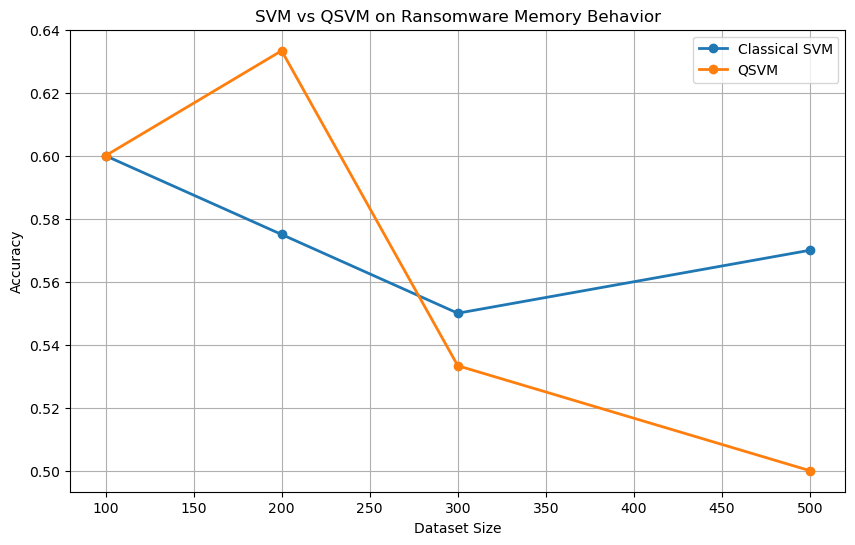


Experiment complete


In [8]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

from qiskit.circuit.library import ZZFeatureMap
from qiskit_machine_learning.kernels import FidelityQuantumKernel

# ==========================================
# DATASET SIZES
# ==========================================

dataset_sizes = [100, 200, 300, 500]

svm_accuracies = []
qsvm_accuracies = []

# ==========================================
# EXPERIMENT LOOP
# ==========================================

for size in dataset_sizes:

    print(f"\nDataset Size: {size}")

    # --------------------------------------
    # SAMPLE DATA
    # --------------------------------------

    idx = np.random.choice(
        len(X_selected),
        size=size,
        replace=False
    )

    X_small = X_selected[idx]
    y_small = y[idx]

    # --------------------------------------
    # SPLIT
    # --------------------------------------

    X_train, X_test, y_train, y_test = train_test_split(
        X_small,
        y_small,
        test_size=0.2,
        stratify=y_small,
        random_state=42
    )

    # --------------------------------------
    # SCALE
    # --------------------------------------

    scaler = StandardScaler()

    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # ======================================
    # CLASSICAL SVM
    # ======================================

    svm = SVC(
        kernel='rbf',
        C=1.0
    )

    svm.fit(X_train, y_train)

    svm_preds = svm.predict(X_test)

    svm_acc = accuracy_score(
        y_test,
        svm_preds
    )

    svm_accuracies.append(svm_acc)

    print(f"SVM Accuracy: {svm_acc:.4f}")

    # ======================================
    # QSVM
    # ======================================

    q_train_size = min(80, len(X_train))
    q_test_size = min(30, len(X_test))

    X_train_q = X_train[:q_train_size]
    y_train_q = y_train[:q_train_size]

    X_test_q = X_test[:q_test_size]
    y_test_q = y_test[:q_test_size]

    feature_map = ZZFeatureMap(
        feature_dimension=2,
        reps=2
    )

    qkernel = FidelityQuantumKernel(
        feature_map=feature_map
    )

    qsvm = SVC(
        kernel=qkernel.evaluate
    )

    qsvm.fit(X_train_q, y_train_q)

    qsvm_preds = qsvm.predict(X_test_q)

    qsvm_acc = accuracy_score(
        y_test_q,
        qsvm_preds
    )

    qsvm_accuracies.append(qsvm_acc)

    print(f"QSVM Accuracy: {qsvm_acc:.4f}")

# ==========================================
# PLOT RESULTS
# ==========================================

plt.figure(figsize=(10,6))

plt.plot(
    dataset_sizes,
    svm_accuracies,
    marker='o',
    linewidth=2,
    label='Classical SVM'
)

plt.plot(
    dataset_sizes,
    qsvm_accuracies,
    marker='o',
    linewidth=2,
    label='QSVM'
)

plt.xlabel("Dataset Size")
plt.ylabel("Accuracy")

plt.title(
    "SVM vs QSVM on Ransomware Memory Behavior"
)

plt.legend()

plt.grid(True)

plt.savefig(
    "qsvm_vs_svm_behavior.png",
    dpi=300
)

plt.show()

print("\nExperiment complete")